In [113]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout


In [115]:
def get_available_symbols(meta_path='symbols_valid_meta.csv', include_etfs=False):
    df = pd.read_csv(meta_path)
    if not include_etfs:
        df = df[df['ETF'] == 'N']
    return df['Symbol'].dropna().unique().tolist()

In [117]:
def load_stock_data(symbol, data_folder="stocks"):
    filepath = os.path.join(data_folder, f"{symbol}.csv")
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File {filepath} does not exist.")
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    return df

In [119]:
def preprocess_data(df, features, sequence_length=60):
    data = df[features].values
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i])
        y.append(scaled_data[i, features.index('Close')])  # Predicting 'Close'
    return np.array(X), np.array(y), scaler

In [121]:
sequence_length = 60
train_ratio = 0.8
epochs = 50
batch_size = 32
features = ['Open', 'High', 'Low', 'Close', 'Volume']

In [123]:
available_symbols = get_available_symbols()
print("Available Stocks:")
print(', '.join(available_symbols[:50]) + ' ...')

Available Stocks:
A, AA, AACG, AAL, AAMC, AAME, AAN, AAOI, AAON, AAP, AAPL, AAT, AAU, AAWW, AAXN, AB, ABB, ABBV, ABC, ABCB, ABEO, ABEV, ABG, ABIO, ABM, ABMD, ABR, ABT, ABTX, ABUS, AC, ACA, ACAD, ACAM, ACAMU, ACB, ACBI, ACC, ACCO, ACEL, ACER, ACGL, ACGLO, ACGLP, ACH, ACHC, ACHV, ACIA, ACIU, ACIW ...


In [125]:
symbol = input("\nEnter the stock symbol you want to analyze (e.g., AAPL): ").upper()
if symbol not in available_symbols:
    print(f"Symbol '{symbol}' not found. Exiting.")
    exit()


Enter the stock symbol you want to analyze (e.g., AAPL):  AAPL


In [127]:
predict_future = input("Do you want to see the predicted next-day stock price? (y/n): ").lower() == 'y'

Do you want to see the predicted next-day stock price? (y/n):  y


In [129]:
df = load_stock_data(symbol)
print(f"\nLoaded {len(df)} records for {symbol}.")


Loaded 9909 records for AAPL.


In [131]:
X, y, scaler = preprocess_data(df, features=features, sequence_length=sequence_length)
split = int(train_ratio * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [133]:
model = Sequential([
    GRU(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(100),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)

Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 7.2766e-05 - val_loss: 1.4306e-05
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 5.7969e-06 - val_loss: 4.8872e-05
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 5.4933e-06 - val_loss: 1.3290e-05
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 4.3154e-06 - val_loss: 1.8802e-05
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 5.0422e-06 - val_loss: 9.2729e-05
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 4.9162e-06 - val_loss: 1.7106e-05
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 3.8682e-06 - val_loss: 4.1556e-05
Epoch 8/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 3.4415e-06 - val_loss: 1.1528e-05
Epoch 9/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 2.9347e-06 - val_loss: 3.3469e-05
Epoch 10/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 3.4554e-06 - val_loss: 6.9703e-05
Epoch 11/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - los

In [135]:
original_close = df['Close'].values.reshape(-1, 1)
close_min = original_close.min()
close_max = original_close.max()

real_prices = y_test.reshape(-1, 1) * (close_max - close_min) + close_min
predicted_prices = model.predict(X_test).reshape(-1, 1) * (close_max - close_min) + close_min

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step 


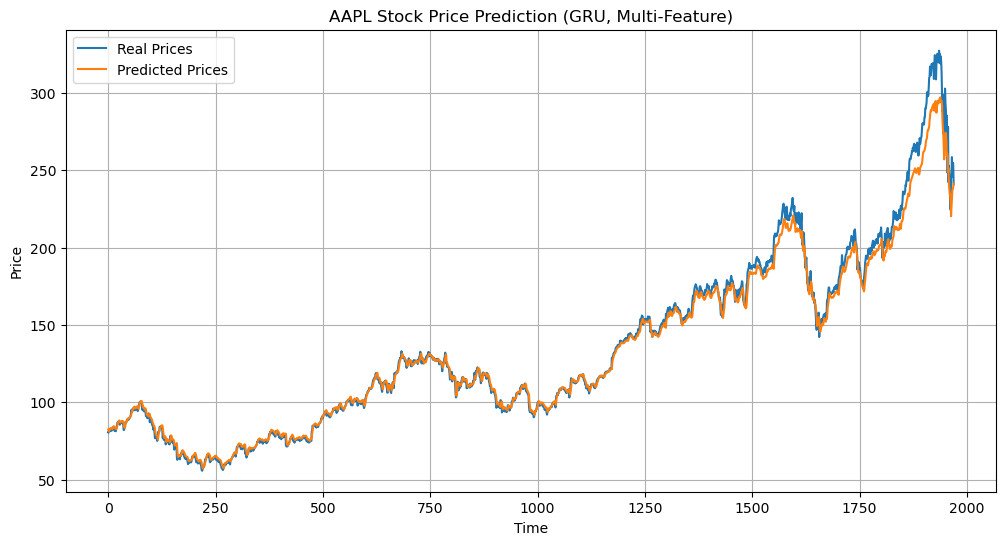

In [137]:
plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Real Prices')
plt.plot(predicted_prices, label='Predicted Prices')
plt.title(f"{symbol} Stock Price Prediction (GRU, Multi-Feature)")
plt.xlabel('Time')
plt.ylabel('Price')
plt.grid(True)
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Predicted next closing price for AAPL: $235.99


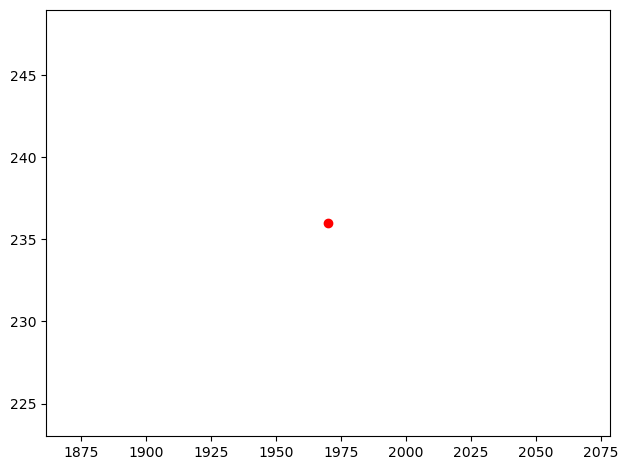

In [139]:
if predict_future:
    last_days = df[features].values[-sequence_length:]
    last_days_scaled = scaler.transform(last_days).reshape(1, sequence_length, len(features))
    next_day_scaled = model.predict(last_days_scaled)

    # Apply manual inverse scaling
    next_day_pred = next_day_scaled * (close_max - close_min) + close_min
    print(f"\nPredicted next closing price for {symbol}: ${next_day_pred[0][0]:.2f}")
    plt.scatter(len(real_prices), next_day_pred[0][0], color='red', label='Next Day Prediction')

plt.tight_layout()
plt.show()

In [141]:
mse = mean_squared_error(real_prices, predicted_prices)
mae = mean_absolute_error(real_prices, predicted_prices)
mape = np.mean(np.abs((real_prices - predicted_prices) / real_prices)) * 100

print(f"\nTest Mean Squared Error (MSE): {mse:.4f}")
print(f"Test Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


Test Mean Squared Error (MSE): 38.7778
Test Mean Absolute Error (MAE): $3.56
Mean Absolute Percentage Error (MAPE): 2.18%
